# MADIS Branch Weight Analysis

Inspects the trained weights of the MADIS branch in `madis_best.keras` to understand which features the model actually learned to use.

In [7]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'
os.environ['TORNET_ROOT'] = '../tornet_data'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
import sys
sys.path.insert(0, '..')

from tornet.models.keras.cnn_baseline import build_model
from tornet.data.constants import ALL_VARIABLES

# Build with 1024/512 head to match the May 22nd saved weights
nn = build_model(
    shape=(120, 240, 2),
    input_variables=ALL_VARIABLES,
    start_filters=48,
    l2_reg=1e-5,
    head='mlp',
    head_units=(1024, 512),
    use_madis=True
)

# Load weights only — avoids Python bytecode version mismatch with Lambda layer
nn.load_weights('../results/run_may_23rd/madis_best.keras')
print('Weights loaded successfully')
print(f'Total layers: {len(nn.layers)}')

Weights loaded successfully
Total layers: 50


In [8]:
# Print all layer names so we can find the MADIS layers
for layer in nn.layers:
    try:
        output_shape = str(layer.output.shape)
    except Exception:
        output_shape = str([o.shape for o in layer.output])
    print(f'{layer.name:40s} {str(layer.__class__.__name__):25s} {output_shape}')

DBZ                                      InputLayer                (None, 120, 240, 2)
VEL                                      InputLayer                (None, 120, 240, 2)
KDP                                      InputLayer                (None, 120, 240, 2)
RHOHV                                    InputLayer                (None, 120, 240, 2)
ZDR                                      InputLayer                (None, 120, 240, 2)
WIDTH                                    InputLayer                (None, 120, 240, 2)
Normalize_DBZ                            Normalization             (None, 120, 240, 2)
Normalize_VEL                            Normalization             (None, 120, 240, 2)
Normalize_KDP                            Normalization             (None, 120, 240, 2)
Normalize_RHOHV                          Normalization             (None, 120, 240, 2)
Normalize_ZDR                            Normalization             (None, 120, 240, 2)
Normalize_WIDTH                          No

## MADIS Dense Layer 1 — Input Weights (7 features → 32 neurons)

In [9]:
FEATURE_NAMES = [
    'pressure (T0)',
    'wind_gust (T0)',
    'pressure_anomaly_24h',
    'wind_anomaly_24h',
    'instability_proxy_T2h',
    'instability_proxy_T0',
]

dense1 = nn.get_layer('madis_dense1')
W1, b1 = dense1.get_weights()
print(f'W1 shape: {W1.shape}')

feature_importance = np.abs(W1).mean(axis=1)

importance_df = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'mean_abs_weight': feature_importance
}).sort_values('mean_abs_weight', ascending=False)

print('Feature importance (mean |weight| into madis_dense1):')
print(importance_df.to_string(index=False))

W1 shape: (6, 32)
Feature importance (mean |weight| into madis_dense1):
              feature  mean_abs_weight
        pressure (T0)         0.178053
       wind_gust (T0)         0.173606
 pressure_anomaly_24h         0.170671
 instability_proxy_T0         0.165143
     wind_anomaly_24h         0.149158
instability_proxy_T2h         0.148903


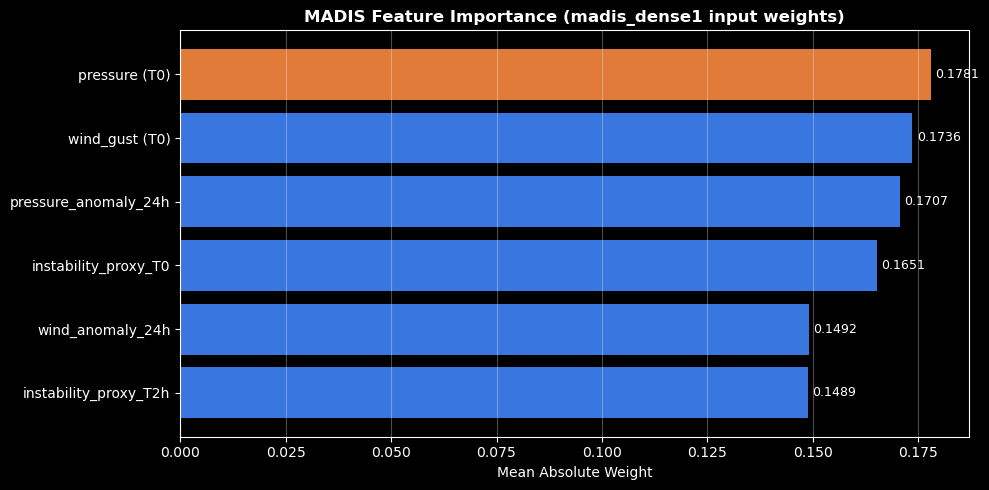

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#e07b39' if v == importance_df['mean_abs_weight'].max() else '#3976e0'
          for v in importance_df['mean_abs_weight']]

bars = ax.barh(importance_df['feature'], importance_df['mean_abs_weight'], color=colors)
ax.set_xlabel('Mean Absolute Weight')
ax.set_title('MADIS Feature Importance (madis_dense1 input weights)', fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

for bar, val in zip(bars, importance_df['mean_abs_weight']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/madis_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Weight Distribution — Are Weights Near Zero?

If the overall weight magnitudes are very small, the MADIS branch may have been effectively suppressed by L2 regularization and dropout.

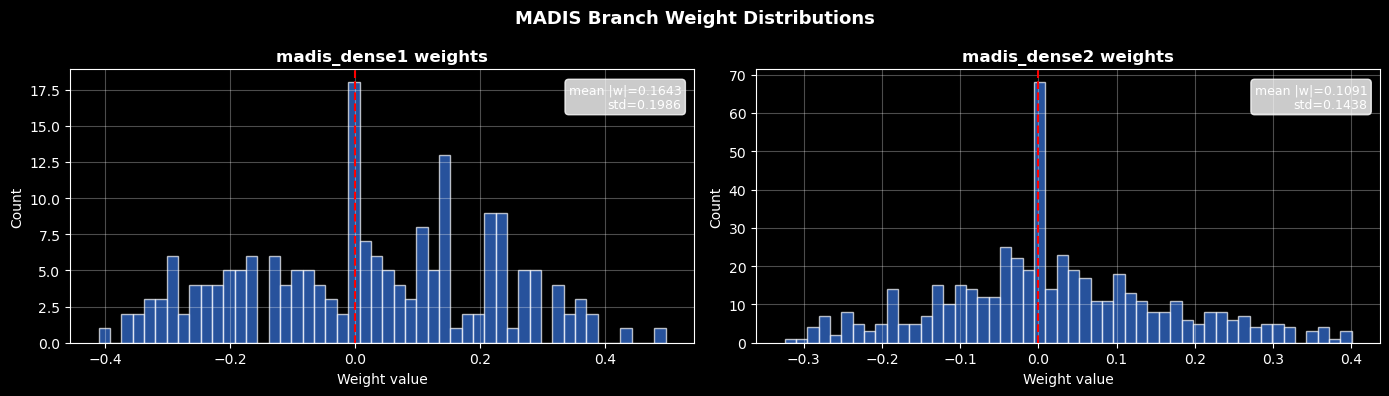

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

dense2 = nn.get_layer('madis_dense2')
W2, b2 = dense2.get_weights()  # W2 shape: (32, 16)

for ax, W, title in zip(axes, [W1, W2], ['madis_dense1 weights', 'madis_dense2 weights']):
    ax.hist(W.flatten(), bins=50, color='#3976e0', alpha=0.7, edgecolor='white')
    ax.axvline(0, color='red', linewidth=1.5, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Weight value')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)
    ax.text(0.98, 0.95, f'mean |w|={np.abs(W).mean():.4f}\nstd={W.std():.4f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('MADIS Branch Weight Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/madis_weight_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-Feature Weight Heatmap

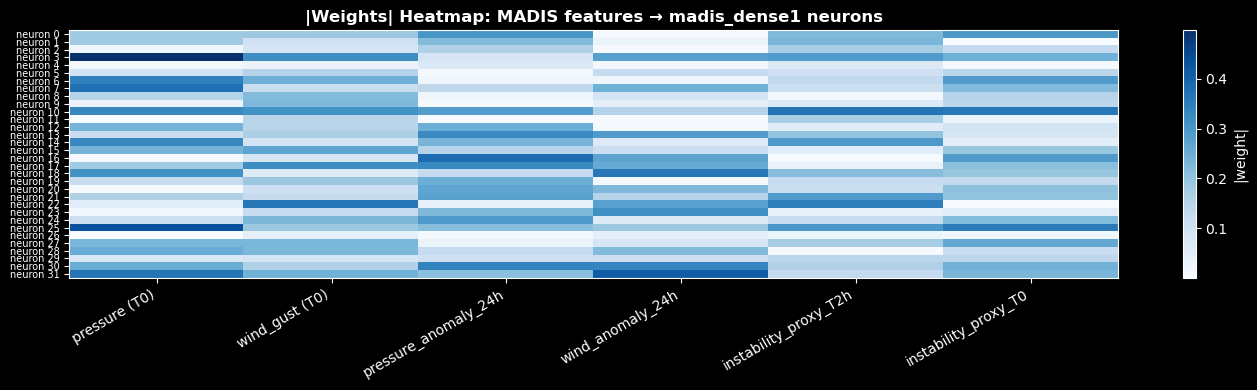

In [12]:
fig, ax = plt.subplots(figsize=(14, 4))

im = ax.imshow(np.abs(W1).T, aspect='auto', cmap='Blues')
ax.set_yticks(range(W1.shape[1]))
ax.set_yticklabels([f'neuron {i}' for i in range(W1.shape[1])], fontsize=7)
ax.set_xticks(range(len(FEATURE_NAMES)))
ax.set_xticklabels(FEATURE_NAMES, rotation=30, ha='right')
ax.set_title('|Weights| Heatmap: MADIS features → madis_dense1 neurons', fontweight='bold')
plt.colorbar(im, ax=ax, label='|weight|')
plt.tight_layout()
plt.savefig('../results/madis_weight_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Interpretation

**If mean |weights| are very small (< 0.01):** The MADIS branch is being largely ignored — L2 regularization and dropout pushed the weights toward zero. The model learned to rely almost entirely on radar features.

**If weights are spread unevenly across features:** Some features are contributing meaningful signal. The highest-weight features are candidates to focus on or engineer further.

**If weights are uniformly near zero across all features:** The MADIS branch is functionally dead in this model — a stronger signal or less aggressive regularization is needed.